# **Xây dựng mô hình phân cụm K-means trên tập dữ liệu mua sắm tại siêu thị**

In [1]:
import numpy as np
import pandas as pd

import plotly.express as px 
import matplotlib.pyplot as plt
import seaborn as sns

import datetime as dt

import plotly.graph_objects as go 

from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv("OnlineRetail.csv", encoding='ISO-8859-1') 
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


## **EDA và xử lý dữ liệu**

In [3]:
#Hiển thị một số thông tin về dữ liệu
# shape
print(f'+ Shape: {data.shape}')
# types
print(f'+ Data Types: \n{data.dtypes}')
# head, tail
print(f'+ Contents: ')
display(data.head(5))
display(data.tail(5))
# info
data.info()

+ Shape: (541909, 8)
+ Data Types: 
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object
+ Contents: 


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,09-12-2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09-12-2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09-12-2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09-12-2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,09-12-2011 12:50,4.95,12680.0,France


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


> **Nhận xét:**

### 1. Tổng quan về kích thước dữ liệu
*   **Kích thước (Shape):** Bộ dữ liệu có **541.909 dòng** và **8 cột**.
*   **Đánh giá:** Đây là một tập dữ liệu khá lớn (nửa triệu dòng).
    *   *Ưu điểm:* Dữ liệu lớn giúp mô hình phản ánh chính xác hơn hành vi khách hàng.
    *   *Nhược điểm:* Sẽ tốn tài nguyên tính toán hơn. Khi chạy thuật toán K-Means hoặc vẽ biểu đồ (như Elbow method), thời gian xử lý sẽ lâu hơn so với các bài tập mẫu (Iris, Mall Customer) bạn đã làm.

### 2. Phân tích từng cột và kiểu dữ liệu (Data Types)

*   **`InvoiceDate` (object):**
    *   **Vấn đề:** Hiện tại đang là kiểu `object` (chuỗi ký tự).
    *   **Hành động bắt buộc:** Đây chính là nguyên nhân gây ra lỗi `TypeError` và `ValueError` mà bạn gặp ở các bước trước. Bạn **bắt buộc** phải chuyển cột này sang `datetime` để tính toán chỉ số **Recency (R)**.

*   **`CustomerID` (float64) & Giá trị thiếu (Missing Values):**
    *   **Quan sát:** Cột này chỉ có **406.829** giá trị `non-null` trên tổng số **541.909** dòng.
    *   **Phân tích:** Có khoảng **135.080 dòng bị thiếu CustomerID** (chiếm ~25% dữ liệu).
    *   **Ý nghĩa:** Đây là những đơn hàng vãng lai hoặc lỗi hệ thống không ghi nhận được danh tính khách.
    *   **Hành động:** Vì bài toán là "Phân cụm khách hàng", nếu không biết khách hàng đó là ai thì không thể phân tích được. Do đó, bước **xóa các dòng có CustomerID = NaN** là hoàn toàn hợp lý và cần thiết.
    *   **Lưu ý phụ:** `CustomerID` đang để kiểu `float64`, sau khi xóa NaN, bạn có thể chuyển nó về `int` hoặc `object` (string) vì ID thực chất là định danh, không dùng để tính toán cộng trừ nhân chia.

*   **`Quantity` (int64) và `UnitPrice` (float64):**
    *   **Kiểu dữ liệu:** Đã đúng định dạng số học.
    *   **Cần kiểm tra thêm:** Trong dữ liệu thực tế của bộ này, `Quantity` thường có giá trị âm (đơn hàng bị trả lại/hủy) và `UnitPrice` có thể bằng 0 (hàng tặng/lỗi).
    *   **Hành động:** Cần lọc bỏ `Quantity <= 0` và `UnitPrice <= 0` để đảm bảo tính toán **Monetary (M)** chính xác (Tổng tiền = Số lượng * Đơn giá).

*   **`Description` (object):**
    *   **Quan sát:** Có một lượng nhỏ giá trị bị thiếu (540.455 non-null).
    *   **Đánh giá:** Với bài toán RFM cơ bản, cột mô tả sản phẩm này không quá quan trọng, có thể bỏ qua hoặc không cần xử lý kỹ.

In [4]:
#Kiểm tra tính toàn vẹn của dữ liệu
# Kiểm tra giá trị null/nan
data_null = data[data.isnull().any(axis=1)]
if not data_null.empty:
    print('Số lượng dòng chứa giá trị null/nan: ', data_null.shape[0])
    display(data_null)
    print("Số lượng giá trị null/nan theo từng cột:")
    print(data.isnull().sum())
else:
    print('Không có giá trị null/nan nào.')

Số lượng dòng chứa giá trị null/nan:  135080


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,01-12-2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,01-12-2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,01-12-2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,01-12-2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,01-12-2010 14:32,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,09-12-2011 10:26,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,09-12-2011 10:26,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,09-12-2011 10:26,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,09-12-2011 10:26,10.79,NaN,United Kingdom


Số lượng giá trị null/nan theo từng cột:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


> **Nhận xét:**

### 1. Vấn đề cốt lõi: Mất định danh khách hàng (`CustomerID`)
*   **Quan sát:** Cột `CustomerID` có tới **135.080** giá trị bị thiếu.
*   **Đối chiếu:** Tổng số dòng chứa giá trị null/nan của toàn bộ dataset cũng chính xác là **135.080**.
*   **Phân tích:** Điều này cho thấy **tất cả** các dòng bị coi là "thiếu dữ liệu" trong bảng này đều xuất phát từ việc thiếu `CustomerID`. Nói cách khác, đây là vấn đề lớn nhất và duy nhất cần quan tâm ở bước này.
*   **Ý nghĩa thực tế:** Trong dữ liệu bán lẻ, những dòng thiếu `CustomerID` thường là:
    *   Khách vãng lai (Guest checkout) không đăng nhập thành viên.
    *   Lỗi hệ thống không ghi nhận được ID.
    *   Các giao dịch không tạo ra giá trị cho việc phân tích hành vi khách hàng cụ thể (vì không biết ai mua để mà phân cụm).

### 2. Về cột `Description`
*   **Quan sát:** Cột `Description` thiếu 1.454 giá trị.
*   **Đánh giá:** Số lượng này rất nhỏ so với 135.080 dòng thiếu CustomerID.
*   **Suy luận logic:** Rất có khả năng 1.454 dòng thiếu mô tả này nằm lọt thỏm trong tập hợp 135.080 dòng thiếu CustomerID kia.
*   **Tác động:** Với thuật toán K-Means dựa trên chỉ số RFM (Recency, Frequency, Monetary), chúng ta chỉ quan tâm đến **Ngày mua, Số lượng và Đơn giá**. Nội dung mô tả sản phẩm (Description) là dữ liệu dạng văn bản, không tham gia vào tính toán toán học của K-Means, nên việc thiếu nó không ảnh hưởng gì đến kết quả cuối cùng.

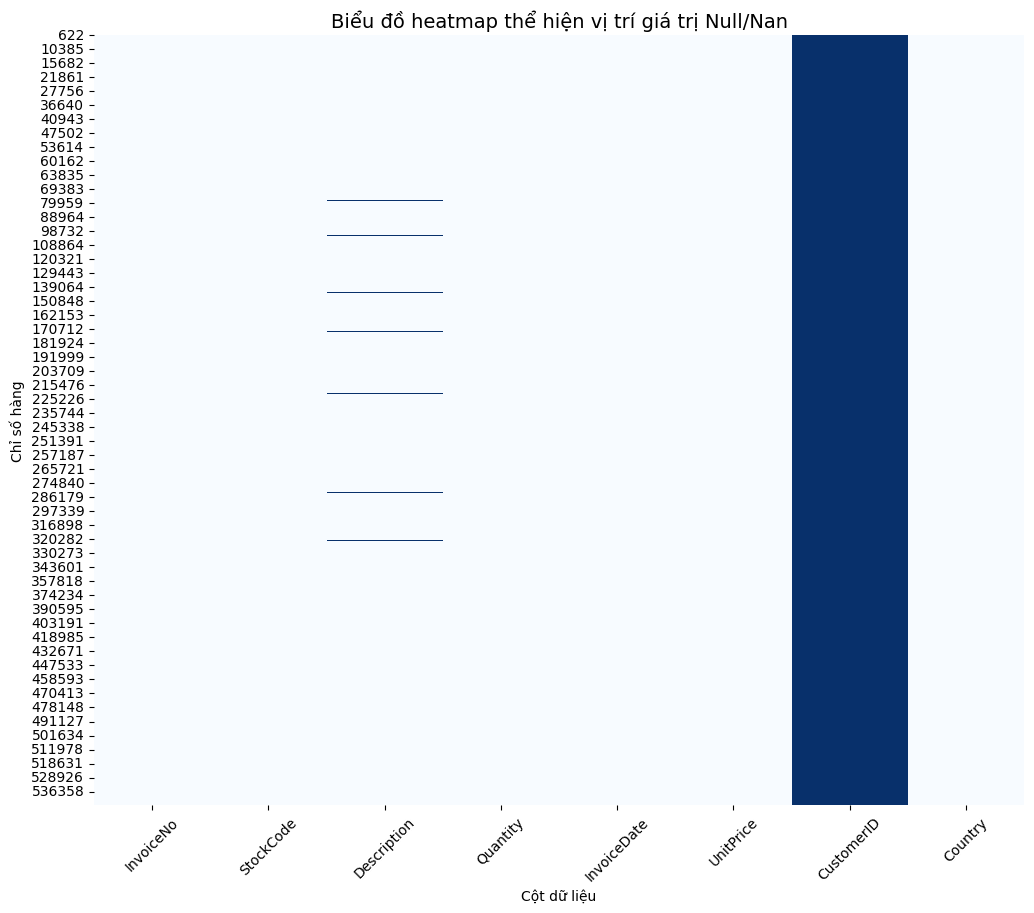

In [5]:
plt.figure(figsize=(12,10))
sns.heatmap(data_null.isnull(), cmap = 'Blues', cbar = False)

plt.title('Biểu đồ heatmap thể hiện vị trí giá trị Null/Nan', fontsize = 14)
plt.xlabel('Cột dữ liệu')
plt.ylabel('Chỉ số hàng')
plt.xticks(rotation=45)
plt.show()
plt.close()

> **Nhận xét:**

### 1. Nhận xét tổng quan
*   **Màu sắc:** Nền trắng đại diện cho dữ liệu đầy đủ (có giá trị). Màu xanh đậm đại diện cho dữ liệu bị thiếu (Null/NaN).
*   **Cấu trúc:** Trục hoành là các cột dữ liệu, trục tung là chỉ số hàng (index) từ 0 đến khoảng hơn 500.000.
*   **Ấn tượng ban đầu:** Biểu đồ khẳng định trực quan rằng cột `CustomerID` là nơi tập trung hầu hết vấn đề của bộ dữ liệu này.

### 2. Phân tích chi tiết từng cột

*   **Cột `CustomerID` (Cột màu xanh đậm lớn nhất bên phải):**
    *   **Hiện tượng:** Cột này bị bao phủ bởi màu xanh đậm dày đặc, trải dài từ đầu đến cuối tập dữ liệu.
    *   **Ý nghĩa:** Điều này cho thấy việc thiếu mã khách hàng không phải là lỗi cục bộ (chỉ xảy ra ở một vài ngày hay một giai đoạn), mà là một **đặc tính hệ thống** xảy ra liên tục trong suốt quá trình thu thập dữ liệu.
    *   **Tỷ lệ:** Nhìn vào mật độ màu xanh, ta thấy nó chiếm một tỷ lệ đáng kể (khoảng 1/4 biểu đồ), khớp với con số tính toán trước đó (135.080 dòng thiếu trên tổng số 541.909 dòng).

*   **Cột `Description` (Các vạch kẻ xanh mỏng):**
    *   **Hiện tượng:** Xuất hiện các vạch kẻ ngang màu xanh rất mảnh và thưa thớt.
    *   **Ý nghĩa:** Số lượng giá trị thiếu ở cột mô tả rất ít.
    *   **Tương quan:** Nếu để ý kỹ, bạn sẽ thấy những dòng thiếu `Description` (vạch xanh bên trái) thường sẽ nằm thẳng hàng ngang với phần thiếu của `CustomerID` (vạch xanh bên phải). Điều này gợi ý rằng: Những giao dịch bị lỗi không có mô tả hàng hóa thì thường cũng sẽ không ghi nhận được thông tin khách hàng.

*   **Các cột còn lại (`InvoiceNo`, `StockCode`, `Quantity`, `InvoiceDate`, `UnitPrice`, `Country`):**
    *   **Hiện tượng:** Hoàn toàn là màu trắng.
    *   **Ý nghĩa:** Dữ liệu ở các cột này rất sạch, không có giá trị null. Đây là tin tốt vì chúng ta không cần xử lý điền khuyết (imputation) cho các thông tin quan trọng như Số lượng hay Đơn giá.

In [6]:
data_dup = data[data.duplicated(keep=False)]
if not data_dup.empty:
    print('Số hàng trùng nhau: ', data.duplicated(keep="first").sum())

    # Nhóm theo toàn bộ các cột
    grouped = data_dup.groupby(list(data.columns))

    # Duyệt và hiển thị từng nhóm
    #for i, (key, group) in enumerate(grouped, start=1):
        #print(f'\n nhóm trùng lặp: {i} (số dòng: {len(group)})')
        #display(group)

    print('Tổng hợp các dòng trùng lặp')
    display(data_dup)
else:
    print('Không có hàng nào trùng nhau.')

Số hàng trùng nhau:  5268
Tổng hợp các dòng trùng lặp


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,01-12-2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,01-12-2010 11:45,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,01-12-2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,01-12-2010 11:45,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,01-12-2010 11:45,2.95,17908.0,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,09-12-2011 11:34,0.39,14446.0,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,09-12-2011 11:34,2.49,14446.0,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,09-12-2011 11:34,1.95,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1,09-12-2011 11:34,2.10,14446.0,United Kingdom


> **Nhận xét:**

### 1. Nhận diện vấn đề (Diagnosis)
*   **Số lượng trùng lặp:** Có **5.268 dòng** dữ liệu trùng nhau hoàn toàn (duplicate rows).
*   **Ý nghĩa:** Đây là những dòng mà tất cả các cột (`InvoiceNo`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `UnitPrice`, `CustomerID`, `Country`) đều y hệt nhau.

### 2. Nguyên nhân có thể (Root Cause Analysis)
Trong ngữ cảnh dữ liệu bán lẻ (Retail Data), hiện tượng này thường xảy ra do:
*   **Lỗi hệ thống (System Glitch):** Hệ thống ghi nhận giao dịch bị "lag" hoặc lỗi mạng, khiến một lần quét mã vạch (scan) bị gửi dữ liệu đi 2 lần.
*   **Thao tác con người (Human Error):** Thu ngân lỡ tay quét một món hàng hai lần, hoặc nhập liệu thủ công bị đúp.
*   **Không phải lỗi (Trường hợp hiếm):** Khách mua 2 món giống hệt nhau, nhưng hệ thống POS (Point of Sale) lại tách thành 2 dòng riêng biệt thay vì gộp lại thành `Quantity = 2`. Tuy nhiên, trong đa số các hệ thống chuẩn, nếu cùng một đơn hàng (`InvoiceNo`), cùng mã hàng (`StockCode`) và cùng thời gian chính xác đến từng giây (`InvoiceDate`), thì thường là do lỗi trùng lặp dữ liệu hơn là mua tách lẻ.

### 3. Tác động đến mô hình K-Means (Impact)
Việc giữ lại 5.268 dòng trùng lặp này sẽ gây ra sai lệch cho mô hình RFM của bạn:
*   **Sai số về Frequency (Tần suất):** Nếu một giao dịch bị nhân đôi, hệ thống sẽ hiểu lầm là khách hàng mua nhiều lần hơn thực tế (dù trong trường hợp này `InvoiceNo` giống nhau nên `nunique` có thể không ảnh hưởng, nhưng nếu tính số dòng dòng chi tiết thì sẽ sai).
*   **Sai số nghiêm trọng về Monetary (Doanh thu):** Đây là nguy cơ lớn nhất. Nếu dòng đó bị lặp lại, tổng tiền (`TotalAmount`) của khách hàng đó sẽ bị cộng dồn sai (tăng gấp đôi giá trị thực của món hàng đó). Điều này khiến khách hàng có thể bị phân loại sai nhóm (ví dụ: từ nhóm "Chi tiêu thấp" nhảy vọt lên nhóm "Chi tiêu trung bình").

In [7]:
#Các tính chất thống kê trên dữ liệu số
description = data.describe().T
display(description)

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


> **Nhận xét:**

### 1. Cột `Quantity` (Số lượng hàng hóa)
*   **Vấn đề nghiêm trọng:** Giá trị nhỏ nhất (`min`) là **-80995**.
    *   **Ý nghĩa:** Số lượng âm trong bán lẻ thường ám chỉ các giao dịch **hoàn trả hàng (Return/Refund)** hoặc đơn bị hủy.
    *   **Tác động:** Nếu để nguyên, các giá trị âm này sẽ làm giảm tổng chi tiêu (Monetary) của khách hàng, thậm chí khiến tổng chi tiêu bị âm, gây sai lệch hoàn toàn cho thuật toán K-Means (vốn dĩ khoảng cách Euclidean không xử lý tốt ý nghĩa của "doanh thu âm" theo cách ta mong muốn phân nhóm hành vi mua sắm).
*   **Sự bất thường (Outlier):** Giá trị lớn nhất (`max`) là **80995** và giá trị nhỏ nhất là **-80995**.
    *   **Nhận xét:** Hai con số này đối xứng nhau tuyệt đối. Điều này gợi ý rằng có ai đó đã đặt một đơn hàng khổng lồ (có thể do lỗi nhập liệu) và sau đó đã hủy nó bằng một giao dịch ngược lại. Đây là nhiễu (noise) điển hình.
*   **Phân phối:** Trung bình (`mean`) là ~9.5, nhưng độ lệch chuẩn (`std`) lên tới ~218. Điều này cho thấy dữ liệu bị biến động cực mạnh bởi các giá trị ngoại lai (outliers) kể trên.

### 2. Cột `UnitPrice` (Đơn giá)
*   **Vấn đề nghiêm trọng:** Giá trị nhỏ nhất (`min`) là **-11062.06**.
    *   **Ý nghĩa:** Giá tiền không thể âm. Trường hợp này thường là do hệ thống ghi nhận các khoản nợ xấu (Bad Debt Adjustments) hoặc các bút toán điều chỉnh kế toán thủ công chứ không phải giao dịch bán hàng thực tế.
*   **Giá trị 0:** Mặc dù bảng không hiển thị rõ số lượng, nhưng với `min` âm và `25%` là 1.25, rất có thể tồn tại các đơn giá bằng 0 (hàng tặng kèm, hàng mẫu).
*   **Giá trị ngoại lai:** Giá trị lớn nhất (`max`) lên tới **38970**. Cần kiểm tra xem đây là món hàng gì mà đắt như vậy, hay lại là phí vận chuyển (Postage) hoặc phí thủ công (Manual) được ghi đè vào cột giá.

### 3. Cột `CustomerID`
*   **Xác nhận lại:** Số lượng (`count`) chỉ có 406.829 so với 541.909 của hai cột kia. Điều này khớp hoàn toàn với phân tích trước đó về việc thiếu dữ liệu định danh khách hàng.
*   **Kiểu dữ liệu:** Các giá trị thống kê (mean, std, min, max) ở cột này **vô nghĩa** về mặt toán học vì `CustomerID` là biến định danh (categorical), không phải biến định lượng.


In [8]:
#Các tính chất thống kê trên dữ liệu phân loại
data.describe(include=['O'])

,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,541909,541909,540455,541909,541909
unique,25900,4070,4223,23260,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,31-10-2011 14:41,United Kingdom
freq,1114,2313,2369,1114,495478


> **Nhận xét:**

### 1. Cột `InvoiceNo` (Mã hóa đơn)
*   **Unique (Số lượng đơn hàng):** Có **25.900** mã hóa đơn duy nhất.
    *   *Ý nghĩa:* Đây là số lượng giao dịch thực tế xảy ra.
*   **Top (Đơn hàng lớn nhất):** Mã hóa đơn `573585` xuất hiện nhiều nhất với **1.114 dòng**.
    *   *Phân tích:* Một hóa đơn mà có tới hơn 1.000 dòng sản phẩm là rất bất thường đối với khách lẻ. Đây có thể là đơn hàng bán buôn (wholesale) hoặc đơn nhập kho của đại lý. Điều này củng cố quan điểm rằng bộ dữ liệu này bao gồm cả khách lẻ và khách buôn (B2B).

### 2. Cột `StockCode` và `Description` (Sản phẩm)
*   **Sự chênh lệch Unique:**
    *   `StockCode` (Mã hàng) có **4.070** giá trị duy nhất.
    *   `Description` (Mô tả) có **4.223** giá trị duy nhất.
    *   *Vấn đề:* Số lượng mô tả nhiều hơn số lượng mã hàng. Điều này cho thấy một mã hàng có thể có nhiều tên gọi khác nhau (do lỗi nhập liệu thủ công hoặc thay đổi tên theo thời gian). Tuy nhiên, điều này không ảnh hưởng nhiều đến mô hình RFM.
*   **Top Product:** Sản phẩm bán chạy nhất là `WHITE HANGING HEART T-LIGHT HOLDER` (Mã 85123A) với tần suất xuất hiện 2.369 lần. Đây là mặt hàng chủ lực của cửa hàng.

### 3. Cột `InvoiceDate` (Ngày hóa đơn)
*   **Unique:** Có **23.260** mốc thời gian khác nhau.
*   **Vấn đề cũ lặp lại:** Cột này vẫn đang nằm trong bảng thống kê `object` (dạng chuỗi), chứng tỏ **bạn CHƯA chuyển đổi nó thành kiểu dữ liệu `datetime` thành công**.
*   **Hành động bắt buộc:** Bạn cần kiểm tra lại code chuyển đổi ngày tháng ngay lập tức. Nếu không chuyển sang `datetime`, bạn không thể trừ ngày để tính chỉ số **Recency**.

### 4. Cột `Country` (Quốc gia)
*   **Unique:** Có **38** quốc gia khác nhau.
*   **Top & Freq:** `United Kingdom` chiếm áp đảo tuyệt đối với **495.478** dòng (chiếm khoảng **91.4%** tổng dữ liệu).
*   **Đánh giá chiến lược cho K-Means:**
    *   Dữ liệu bị mất cân bằng nghiêm trọng về địa lý.
    *   Hành vi mua sắm của khách trong nước (UK) và khách quốc tế (thường phải chịu phí ship cao, thời gian chờ lâu) sẽ rất khác nhau.
    *   **Lời khuyên:** Để mô hình K-Means hoạt động hiệu quả và chính xác nhất, bạn nên **lọc và chỉ chạy mô hình cho thị trường United Kingdom**. Việc gộp chung cả khách quốc tế vào có thể tạo ra các cụm nhiễu (ví dụ: cụm những người mua cực ít nhưng phí ship cực cao).

In [9]:
data_copy = data.copy()

### Hiển thị trên từng tính chất đơn (Univariate Plots)

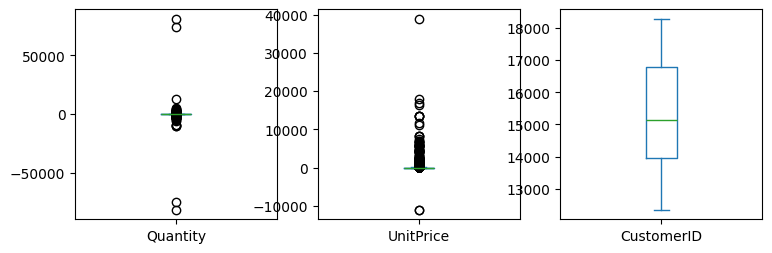

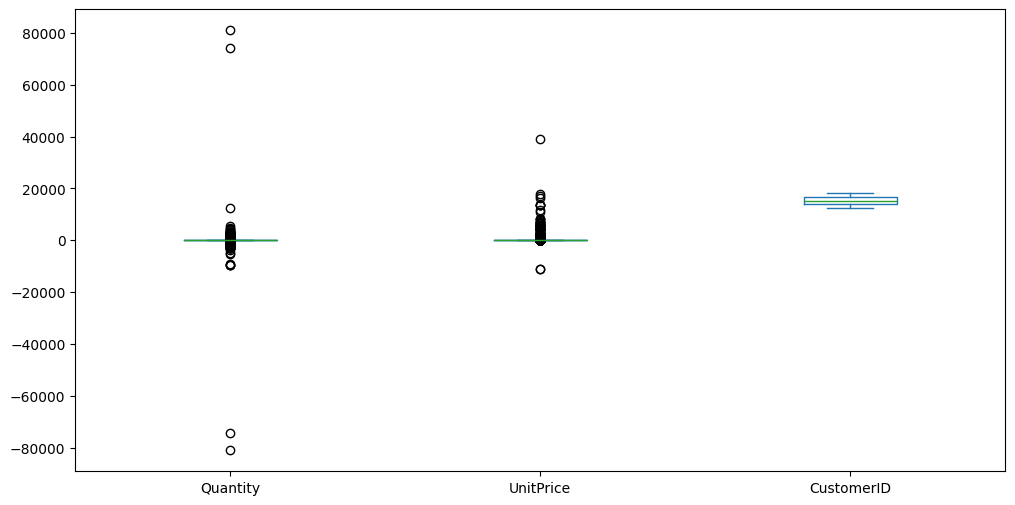

In [10]:
data.plot(kind="box", subplots=True, layout=(2, 4), sharex=False, sharey=False, figsize=(12,6))
data.plot(kind="box", figsize=(12,6))
plt.show()
plt.close()

> **Nhận xét:**

### 1. Phân tích Biểu đồ `Quantity` (Số lượng)
*   **Hiện tượng:** Biểu đồ bị "ép dẹp" lại ở giữa (quanh số 0) đến mức không thấy được cái "hộp" đâu cả. Lý do là vì sự xuất hiện của hai điểm dữ liệu cực đoan nằm ở vị trí **+80.000** và **-80.000**.
*   **Đánh giá:**
    *   Đây là minh chứng hình ảnh cho cặp giao dịch "mua - hủy" khổng lồ mà chúng ta đã nghi ngờ ở bảng thống kê trước (describe).
    *   Ngoài 2 điểm cực trị này, còn rất nhiều điểm đen (outliers) khác nằm rải rác ở vùng âm (trả hàng) và vùng dương cao (> 10.000).
*   **Tác động:** Nếu đưa nguyên cột này vào mô hình, khoảng cách Euclidean trong K-Means sẽ bị kéo giãn cực đại, làm hỏng toàn bộ cấu trúc phân cụm.

### 2. Phân tích Biểu đồ `UnitPrice` (Đơn giá)
*   **Hiện tượng:** Tương tự như Quantity, biểu đồ cũng bị biến dạng bởi các giá trị bất thường.
    *   Có điểm dữ liệu âm xuống tới mức **-10.000** (đây chính là khoản nợ xấu/điều chỉnh kế toán).
    *   Có điểm dữ liệu dương vọt lên gần **40.000**.
*   **Đánh giá:** Với mặt hàng bán lẻ thông thường (quà lưu niệm, đồ gia dụng...), một món hàng có đơn giá ~40.000 bảng Anh (hơn 1 tỷ VND) là cực kỳ đáng ngờ. Khả năng cao đây là phí "AMAZON FEE", "Manual", "POSTAGE" hoặc các bút toán thủ công khác, không phải hành vi mua sắm của khách hàng.

### 3. Phân tích Biểu đồ `CustomerID`
*   **Hiện tượng:** Biểu đồ này trông "đẹp" và cân đối nhất.
*   **Nhưng... vô nghĩa:** Thực tế, `CustomerID` là mã định danh (dạng Category), không phải là biến định lượng (Numeric) có ý nghĩa đo lường. Việc vẽ biểu đồ hộp cho ID chỉ cho chúng ta biết dải số ID tập trung ở đâu (từ 12.000 đến 18.000), chứ không giúp ích gì cho việc phát hiện bất thường trong hành vi mua sắm.

### 4. So sánh giữa Ảnh 9 và Ảnh 10
*   **Ảnh 9 (3 biểu đồ riêng):** Giúp nhìn rõ biên độ của từng biến.
*   **Ảnh 10 (Gộp chung):** Cho thấy sự chênh lệch về độ lớn (scale) giữa các biến. `Quantity` có biên độ dao động quá lớn (từ -80k đến +80k) so với `CustomerID` (chỉ dao động trong khoảng hẹp 12k-18k).
*   **Bài học rút ra:** Điều này nhắc nhở chúng ta rằng trước khi chạy K-Means, bắt buộc phải **Chuẩn hóa dữ liệu (Scaling)**. Nếu không, biến nào có giá trị lớn hơn (như Quantity) sẽ áp đảo hoàn toàn các biến khác.

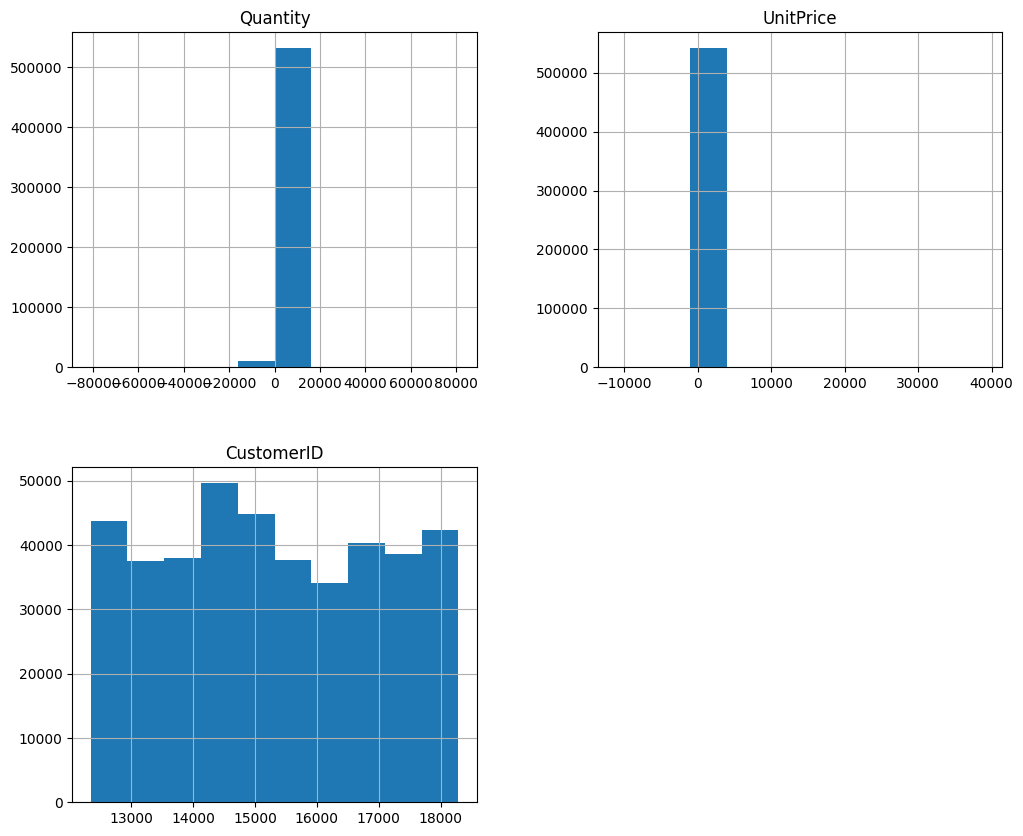

In [11]:
numeric_cols = data.select_dtypes(include='number')
numeric_cols.hist(figsize=(12,10))
plt.show()
plt.close()

> **Nhận xét:**

### 1. Tổng quan
Hình ảnh hiển thị 3 biểu đồ histogram (biểu đồ phân phối tần suất) cho 3 biến số khác nhau: **Quantity** (Số lượng), **UnitPrice** (Đơn giá), và **CustomerID** (Mã khách hàng). Đây là một bước thường thấy trong giai đoạn Khám phá dữ liệu (Exploratory Data Analysis - EDA) để hiểu về phân phối và phát hiện các điểm bất thường (outliers).

### 2. Phân tích chi tiết từng biểu đồ

#### a. Biểu đồ Quantity (Số lượng)
*   **Đặc điểm:** Dữ liệu tập trung cực kỳ lớn ở quanh mức 0. Cột ở giữa cao vọt lên tới hơn 500,000 quan sát.
*   **Trục hoành (X-axis):** Trải rất rộng từ khoảng -80,000 đến +80,000.
*   **Vấn đề phát hiện:**
    *   **Giá trị âm:** Có sự xuất hiện của số lượng âm (Quantity < 0). Trong bán lẻ, điều này thường đại diện cho hàng bị trả lại (returns), hàng hủy, hoặc lỗi nhập liệu. Các giá trị âm này kéo dài tới tận -80,000, cho thấy có những đơn trả hàng hoặc hủy đơn với số lượng cực lớn.
    *   **Giá trị dương cực đại:** Cũng có những đơn hàng với số lượng rất lớn (lên tới 80,000), đây có thể là đơn bán buôn (wholesale) chứ không phải bán lẻ thông thường.
*   **Nhận xét:** Phân phối bị lệch nặng (highly skewed) và chứa nhiều điểm ngoại lai (outliers) cực đoan ở cả hai phía âm và dương.

#### b. Biểu đồ UnitPrice (Đơn giá)
*   **Đặc điểm:** Tương tự như biểu đồ Quantity, dữ liệu tập trung hầu hết ở mức thấp gần 0.
*   **Trục hoành (X-axis):** Có sự xuất hiện của giá trị âm (khoảng -10,000) và giá trị dương rất lớn (lên tới 40,000).
*   **Vấn đề phát hiện:**
    *   **Giá trị âm:** Đơn giá âm là điều bất thường trong kinh doanh. Nó có thể là các khoản điều chỉnh nợ (bad debt adjustments) hoặc lỗi hệ thống.
    *   **Outlier:** Có một số ít sản phẩm có giá trị cực cao (khoảng 30,000 - 40,000) so với mặt bằng chung, làm biểu đồ bị "bẹp" xuống, không thấy rõ phân phối của các mức giá phổ thông.
*   **Nhận xét:** Dữ liệu này cần được làm sạch. Cần loại bỏ hoặc xử lý riêng các giá trị âm và xem xét kỹ các mặt hàng có giá quá cao.

#### c. Biểu đồ CustomerID (Mã khách hàng)
*   **Đặc điểm:** Dữ liệu phân bố khá đều (uniform distribution) hơn so với hai biểu đồ trên. Các cột có chiều cao tương đối đồng đều, dao động từ khoảng 35,000 đến 50,000.
*   **Trục hoành (X-axis):** Mã khách hàng nằm trong khoảng từ 12,000 đến 18,000.
*   **Ý nghĩa:** Điều này cho thấy các giao dịch được thực hiện bởi lượng khách hàng đa dạng, không có một nhóm mã khách hàng nào chiếm ưu thế quá áp đảo hay quá ít xuất hiện.
*   **Nhận xét:** Biểu đồ này trông bình thường nhất và phản ánh đúng tính chất của mã định danh (ID).

### Bước 2: Làm sạch dữ liệu (Data Cleaning)

In [12]:
#Chuyển đổi cột InvoiceDate sang định dạng datetime
data_copy['InvoiceDate'] = pd.to_datetime(data_copy['InvoiceDate'], dayfirst=True, format='mixed') 

# 1. Loại bỏ các dòng không có CustomerID (vì ta cần phân cụm khách hàng)
data_copy = data_copy.dropna(subset=['CustomerID'])

# 2. Loại bỏ các đơn hàng bị hủy (Quantity < 0) và UnitPrice <= 0
data_copy = data_copy[(data_copy['Quantity'] > 0) & (data_copy['UnitPrice'] > 0)]

# 3. Tạo cột Tổng tiền (TotalAmount) = Số lượng * Đơn giá
data_copy['TotalAmount'] = data_copy['Quantity'] * data_copy['UnitPrice']

# Kiểm tra lại thông tin
data_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   TotalAmount  397884 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


> **Nhận xét:**

### 1. Dữ liệu đã sạch và đồng nhất (Data Completeness)
*   **Không còn giá trị rỗng (No Null Values):**
    *   Tất cả 9 cột đều hiển thị `397884 non-null`. Điều này có nghĩa là đã xử lý triệt để các dữ liệu bị thiếu (Missing values).
    *   Đặc biệt là cột `CustomerID` và `Description` (thường hay bị thiếu trong bộ dữ liệu bán lẻ này) giờ đã đầy đủ 100%. Điều này rất quan trọng để thực hiện phân tích hành vi khách hàng (RFM analysis) sau này.

### 2. Sự sụt giảm số lượng bản ghi (Data Reduction)
*   **Quan sát:** Index ban đầu chạy đến `541908`, nhưng hiện tại chỉ còn `397884 entries`.
*   **Phân tích:**
    *  Đã loại bỏ khoảng **144,024 dòng** (tương đương giảm khoảng **26.5%** dữ liệu).
    *   **Nguyên nhân khả dĩ:** xóa các dòng có `CustomerID` bị `null` (thường chiếm tỷ trọng lớn) và các dòng có `Quantity` âm (hàng trả lại/hủy) như đã phân tích ở hình 1.
    *   **Đánh giá:** Đây là mức sụt giảm chấp nhận được để đảm bảo độ sạch ("high quality data") cho mô hình.

### 3. Kiểu dữ liệu (Data Types) đã chuẩn hóa
*   **InvoiceDate (datetime64[ns]):** Rất tốt. Việc chuyển đổi từ `object` sang `datetime` cho phép thực hiện các phân tích theo thời gian (time-series), tính toán Recency (thời gian từ lần mua cuối), hoặc trích xuất ngày/tháng/năm dễ dàng.
*   **Quantity (int64) & UnitPrice (float64):** Đã đúng định dạng số học để tính toán.

### 4. Đã có bước Feature Engineering (Tạo đặc trưng mới)
*   Sự xuất hiện của cột **`TotalAmount`** (float64).
*   Đây là cột không có trong dữ liệu gốc. Có thể đã tạo nó bằng công thức `Quantity * UnitPrice`. Đây là biến quan trọng nhất để tính chỉ số Monetary (Doanh thu) cho từng khách hàng.

### Bước 3: Feature Engineering - Phân tích RFM

Đây là bước quan trọng nhất để biến đổi dữ liệu.

* Recency (R): Số ngày kể từ lần mua cuối cùng.
* Frequency (F): Số lượng đơn hàng (InvoiceNo) duy nhất.
* Monetary (M): Tổng số tiền khách đã chi tiêu.

In [13]:
# Chọn mốc thời gian tham chiếu (lấy ngày cuối cùng trong dữ liệu + 1 ngày)
ref_date = data_copy['InvoiceDate'].max() + dt.timedelta(days=1)

# Group by CustomerID để tính R, F, M
rfm = data_copy.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (ref_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                             # Frequency
    'TotalAmount': 'sum'                                # Monetary
})

# Đổi tên cột cho dễ hiểu
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'
}, inplace=True)

print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


> **Nhận xét:**

### 1. Tổng quan về cấu trúc bảng
Bảng kết quả đã được tổng hợp (aggregate) chính xác theo từng khách hàng (`CustomerID`). Các chỉ số RFM cơ bản đã được tính toán đầy đủ:
*   **Recency (R):** Số ngày kể từ lần mua cuối cùng.
*   **Frequency (F):** Tần suất mua hàng (số lần giao dịch).
*   **Monetary (M):** Tổng số tiền đã chi tiêu.

### 2. Phân tích từng chỉ số qua các ví dụ cụ thể
Dựa vào 5 khách hàng đầu tiên trong bảng, ta thấy sự phân hóa hành vi rất rõ rệt:

*   **Khách hàng 12346.0 (Trường hợp dị biệt - Outlier):**
    *   *Recency: 326* (Rất lâu chưa quay lại - gần 1 năm).
    *   *Frequency: 1* (Chỉ mua đúng 1 lần).
    *   *Monetary: 77,183.60* (Chi tiêu cực khủng).
    *   **Đánh giá:** Đây là khách hàng "Vãng lai chi tiêu lớn" (Whale). Họ mua một lượng hàng khổng lồ trong một lần duy nhất và biến mất. Cần kiểm tra kỹ xem đây có phải là đơn hàng bán buôn, đơn hàng dự án, hay có sự nhầm lẫn về số liệu không. Nếu đây là dữ liệu thật, chiến lược là tìm cách liên lạc để mời họ quay lại (Win-back), nhưng khả năng thành công thấp vì Recency quá cao.

*   **Khách hàng 12347.0 (Khách hàng lý tưởng - Champion/Loyal):**
    *   *Recency: 2* (Mới mua 2 ngày trước).
    *   *Frequency: 7* (Mua 7 lần - tần suất cao).
    *   *Monetary: 4,310.00* (Chi tiêu khá cao).
    *   **Đánh giá:** Đây là mẫu hình khách hàng trung thành điển hình: Mua thường xuyên, mới mua gần đây và chi tiêu tốt. Cần chăm sóc đặc biệt để duy trì.

*   **Khách hàng 12348.0 (Khách hàng tiềm năng):**
    *   *Recency: 75* (Hơn 2 tháng chưa mua).
    *   *Frequency: 4* (Tần suất trung bình).
    *   *Monetary: 1,797.24*.
    *   **Đánh giá:** Khách này có tiềm năng nhưng đang có dấu hiệu rời bỏ (Churn risk) vì Recency đang tăng lên (75 ngày). Cần gửi email marketing hoặc khuyến mãi để kích thích họ mua lại.

*   **Khách hàng 12349.0 (Khách hàng mới đầy hứa hẹn):**
    *   *Recency: 19* (Mới mua gần đây).
    *   *Frequency: 1* (Mới mua 1 lần).
    *   *Monetary: 1,757.55* (Giá trị đơn hàng đầu tiên cao).
    *   **Đánh giá:** Đây có thể là khách hàng mới (New Customer) nhưng có giá trị đơn hàng cao. Cần chiến lược "Onboarding" tốt để biến họ thành khách hàng mua lại lần 2.

*   **Khách hàng 12350.0 (Khách hàng đã mất/Cần loại bỏ):**
    *   *Recency: 310* (Gần 1 năm không mua).
    *   *Frequency: 1* (Mua 1 lần duy nhất).
    *   *Monetary: 334.40* (Giá trị thấp).
    *   **Đánh giá:** Khách hàng vãng lai giá trị thấp và đã rời bỏ từ lâu. Không nên tốn chi phí marketing cho nhóm này.

### 3. Đánh giá chất lượng Output
*   **Tính chính xác:** Các con số trông hợp lý (Recency là số nguyên dương, Monetary là số thực).
*   **Vấn đề nhỏ cần lưu ý:**
    *   `CustomerID` vẫn đang để dạng `float` (12346.0), nên chuyển về `int` hoặc `string` để đẹp hơn khi hiển thị báo cáo.
    *   **Đơn vị tính Recency:** Cần chắc chắn `Recency` đang tính bằng "Ngày". Nhìn vào con số 326 và 310, có vẻ đơn vị này là chính xác.

### Bước 4: Xử lý dữ liệu (Data Preprocessing)

In [14]:
# 1. Xử lý độ lệch (Skewness) bằng Log Transformation
# Sử dụng np.log1p để tránh lỗi log(0) nếu có
rfm_log = np.log(rfm) 
# Nếu dữ liệu có giá trị <= 0, hãy xử lý trước hoặc dùng np.log1p(rfm)

# 2. Chuẩn hóa dữ liệu (StandardScaler)
scaler = StandardScaler()
scaler.fit(rfm_log)
rfm_normalized = scaler.transform(rfm_log)

# Tạo DataFrame cho dữ liệu đã chuẩn hóa
rfm_scaled = pd.DataFrame(rfm_normalized, index=rfm.index, columns=rfm.columns)
print(rfm_scaled.head())

             Recency  Frequency  Monetary
CustomerID                               
12346.0     1.409894  -1.048610  3.698719
12347.0    -2.146498   1.111836  1.410201
12348.0     0.383971   0.490522  0.716419
12349.0    -0.574674  -1.048610  0.698706
12350.0     1.374758  -1.048610 -0.617446


### Bước 5: Tìm số cụm tối ưu

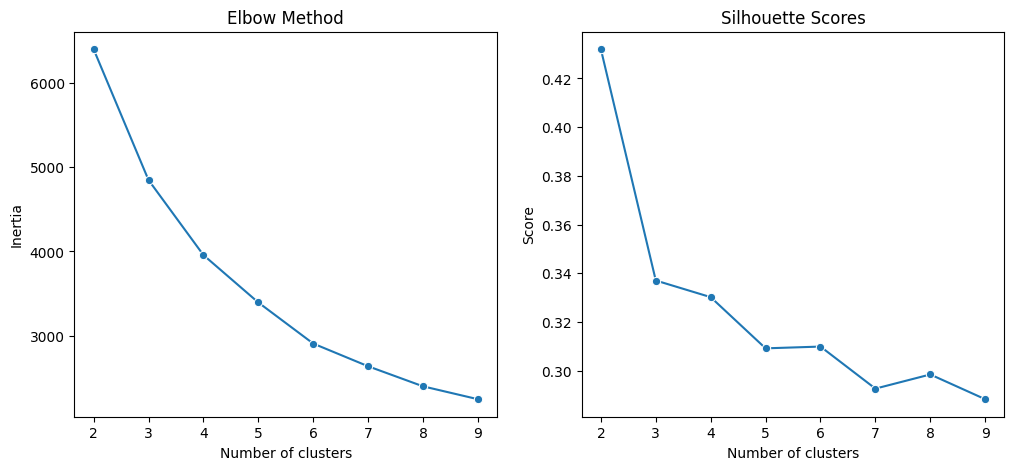

In [15]:
km_inertias, km_scores = [], []
K_range = range(2, 10) # Thử từ 2 đến 10 cụm

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42).fit(rfm_scaled)
    km_inertias.append(km.inertia_)
    km_scores.append(silhouette_score(rfm_scaled, km.labels_))
    
# Vẽ biểu đồ Elbow
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
sns.lineplot(x=K_range, y=km_inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

# Vẽ biểu đồ Silhouette
plt.subplot(1, 2, 2)
sns.lineplot(x=K_range, y=km_scores, marker='o')
plt.title('Silhouette Scores')
plt.xlabel('Number of clusters')
plt.ylabel('Score')

plt.show()

> **Nhận xét:**

### 1. Phân tích biểu đồ Elbow Method (Bên trái)
*   **Mục đích:** Tìm điểm mà tại đó độ giảm của quán tính (Inertia - tổng bình phương khoảng cách từ các điểm đến tâm cụm) bắt đầu chững lại, tạo thành hình "khuỷu tay".
*   **Quan sát:**
    *   Đường cong giảm dần khi số cụm tăng lên (điều này là hiển nhiên).
    *   Độ dốc giảm mạnh từ $k=2$ đến $k=3$.
    *   Từ $k=3$ đến $k=4$, độ dốc vẫn còn khá lớn.
    *   Sau $k=4$, độ dốc bắt đầu thoải dần và trở nên tuyến tính hơn (ít gập khúc hơn).
*   **Đánh giá:** Điểm "khuỷu tay" không thực sự sắc nét và rõ ràng (một hiện tượng thường gặp trong dữ liệu thực tế). Tuy nhiên, **$k=3$ hoặc $k=4$** có vẻ là những ứng viên sáng giá nhất tại đây.

### 2. Phân tích biểu đồ Silhouette Scores (Bên phải)
*   **Mục đích:** Đo lường độ tách biệt giữa các cụm. Giá trị càng gần 1 càng tốt (các cụm tách biệt rõ ràng), càng gần 0 (các cụm chồng lấn), âm (phân sai cụm).
*   **Quan sát:**
    *   **$k=2$:** Đạt điểm cao nhất (khoảng 0.43). Điều này cho thấy chia làm 2 nhóm là tách biệt rõ nhất về mặt toán học.
    *   **$k=3$:** Điểm giảm mạnh xuống còn khoảng 0.34.
    *   **$k=4$:** Điểm tiếp tục giảm nhẹ xuống khoảng 0.33.
    *   Từ $k=5$ trở đi: Điểm thấp và dao động không đáng kể (quanh mức 0.30 - 0.31).
*   **Đánh giá:**
    *   Về mặt thuần túy kỹ thuật, $k=2$ là tốt nhất.
    *   Tuy nhiên, $k=3$ và $k=4$ có điểm số không chênh lệch nhau quá nhiều và vẫn ở mức chấp nhận được (> 0.3).

### 3. Tổng hợp và Khuyến nghị Lựa chọn K (Số cụm tối ưu)

Khi kết hợp cả hai biểu đồ, chúng ta có một sự cân nhắc ("Trade-off") giữa kỹ thuật và ý nghĩa kinh doanh:

*   **Lựa chọn $k=2$:**
    *   *Ưu điểm:* Silhouette score cao nhất, các cụm tách bạch nhất.
    *   *Nhược điểm:* **Quá ít ý nghĩa kinh doanh.** Chia khách hàng chỉ thành 2 nhóm (ví dụ: "Mua ít" và "Mua nhiều") thường không đủ chi tiết để chạy các chiến dịch marketing mục tiêu (targeted marketing).
*   **Lựa chọn $k=3$:**
    *   *Ưu điểm:* Điểm Silhouette khá tốt (đứng thứ 2), nằm ở vùng gập của Elbow method.
    *   *Ý nghĩa kinh doanh:* Có thể chia thành 3 nhóm cơ bản: Thấp - Trung bình - Cao (Low, Mid, High Value). Đây là cách chia an toàn và dễ giải thích.
*   **Lựa chọn $k=4$ (Khuyên dùng):**
    *   *Lý do:* Mặc dù điểm Silhouette thấp hơn $k=2$ và $k=3$ một chút, nhưng điểm gập ở Elbow method tại $k=4$ vẫn khá rõ.
    *   *Ý nghĩa kinh doanh:* 4 nhóm thường mang lại độ phân giải tốt hơn (Granularity) cho đội ngũ Marketing. Ví dụ:
        1.  **VIP/Loyal:** Chi nhiều, mua thường xuyên.
        2.  **Potential:** Chi khá, tần suất trung bình.
        3.  **New/Promising:** Mới mua, chi ít nhưng có tiềm năng.
        4.  **Lost/Low Value:** Đã lâu không mua, chi ít.

### Bước 6: Training mô hình và Gán nhãn

In [16]:

km = KMeans(n_clusters = 4,  
        init = 'k-means++',  
        max_iter = 300, n_init = 10, random_state = 42)
clusters = km.fit(rfm_scaled)

# Gán nhãn cụm vào dữ liệu gốc (chưa scale) để dễ phân tích
rfm['Cluster'] = km.labels_

# Thống kê đặc tính từng cụm
print(rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster': 'count' # Đếm số lượng khách trong mỗi cụm
}))

            Recency  Frequency     Monetary  Cluster
Cluster                                             
0         18.721053   1.996053   503.879526      760
1         10.595206  13.121172  7739.896977      751
2         72.788048   4.120319  1735.427317     1255
3        183.135496   1.265903   342.134574     1572


In [20]:
# Lấy tọa độ tâm cụm
centroids = km.cluster_centers_

# 1. Vẽ các điểm dữ liệu (Tô màu theo Cluster thay vì Sex)
fig = px.scatter(
    data_frame=rfm, 
    x='Recency', # Đảm bảo tên cột đúng
    y='Frequency',  # Đảm bảo tên cột đúng
    color='Cluster',      # <--- SỬA LẠI CHỖ NÀY (Quan trọng nhất)
    template='seaborn',
    title='K-means Clustering Results (Phân theo Cụm)'
)

# 2. Vẽ thêm các dấu X tâm cụm
fig.add_trace(
    go.Scatter(
        x=centroids[:, 0], # Cột 0 tương ứng với x='culmen_length_mm'
        y=centroids[:, 1], # Cột 1 tương ứng với y='culmen_depth_mm'
        mode='markers',
        marker=dict(color='#CAC9CD', size=15, symbol='x'),
        name='Centroids'
    )
)

fig.update_layout(template='plotly_dark',width=1000, 
height=500,title='Kmean Clustering Results') 

fig.show()

> **Nhận xét:**

*   **Hình dạng phân bố:** Biểu đồ này cho thấy mối quan hệ giữa "Độ mới" (Recency) và "Tần suất" (Frequency).
*   **Trục hoành (Recency):** Các điểm trải dài từ 0 đến hơn 350 ngày.
*   **Trục tung (Frequency):** Phần lớn tập trung ở mức thấp (< 50), nhưng có một số điểm vọt lên rất cao (> 200).
*   **Các cụm quan sát được (Clusters):**
    *   **Cụm màu sáng (trắng/be):** Tập trung ở Recency cao (> 100) và Frequency thấp. Đây là nhóm **khách hàng ngủ đông hoặc đã rời bỏ**.
    *   **Cụm màu cam/đỏ:** Nằm ở Recency thấp (< 50) và Frequency thấp đến trung bình. Đây là nhóm **khách hàng mới hoặc khách hàng vãng lai**.
    *   **Cụm màu tím/hồng đậm:** Tập trung sát gốc tọa độ (Recency cực thấp) nhưng Frequency rất cao. Đây chính là nhóm **Khách hàng trung thành/VIP**.
*   **Đánh giá:** Biểu đồ 2D này cho thấy sự phân tách khá tốt theo chiều dọc (Frequency) và chiều ngang (Recency). Nhóm VIP tách biệt hẳn lên phía trên bên trái.

In [19]:
# Đừng quên dùng dữ liệu GỐC (chưa scale) để hiển thị tooltip cho dễ hiểu
# Nhưng tô màu (color) thì dùng kết quả label từ K-means

fig = px.scatter_3d(
    rfm_scaled, # Nên dùng df gốc để hiện số thực (gram, mm)
    x='Recency', 
    y='Frequency', 
    z='Monetary',  # Thêm chiều cân nặng
    color=km.labels_.astype(str), # Tô màu theo cụm K-means tìm được
    color_discrete_sequence=['#491D8B', '#EB548C', "#C1B43A","#3AC13C"],
    title='Kết quả phân cụm K-means trong không gian 3D',
    opacity=0.7
)
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

> **Nhận xét:**

### Phân tích biểu đồ 3D (Recency - Frequency - Monetary )

Các biểu đồ 3D cung cấp cái nhìn toàn diện hơn khi thêm chiều "Doanh thu" (Monetary). Trục số liệu trong biểu đồ 3D dường như đã được **chuẩn hóa (Standardized/Normalized)** (vì giá trị nằm trong khoảng -4 đến +4). Điều này là **rất tốt và đúng đắn** khi chạy K-Means.

Dựa trên màu sắc (Color 0, 1, 2, 3), ta có thể định danh các nhóm khách hàng như sau:

*   **Nhóm màu hồng (Cluster 1):**
    *   **Đặc điểm:** Monetary cao (trục đứng vươn lên cao), Frequency cao, Recency thấp.
    *   **Định danh:** **VIP / Champions**. Đây là nhóm khách hàng quý giá nhất. Họ mua nhiều, mua gần đây và chi tiêu lớn.
    *   **Hành động:** Chăm sóc đặc biệt, tặng quà, ưu đãi độc quyền để giữ chân.

*   **Nhóm màu xanh lá cây (Cluster 3):**
    *   **Đặc điểm:** Recency rất thấp (trục Recency giá trị âm sau khi chuẩn hóa, nghĩa là số ngày thấp), Frequency thấp, Monetary thấp.
    *   **Định danh:** **New Customers / Promising**. Khách mới mua gần đây nhưng chưa chi nhiều.
    *   **Hành động:** Upsell, Cross-sell để tăng giá trị đơn hàng.

*   **Nhóm màu vàng (Cluster 0):**
    *   **Đặc điểm:** Nằm ở khoảng giữa của các chỉ số, Monetary và Frequency ở mức trung bình.
    *   **Định danh:** **Potential Loyalists**. Khách hàng tiềm năng, cần một cú hích để trở thành VIP.
    *   **Hành động:** Gửi mã giảm giá khi mua số lượng lớn, chương trình tích điểm.

*   **Nhóm màu tím than (Cluster 2):**
    *   **Đặc điểm:** Recency cao (trục Recency giá trị dương lớn sau chuẩn hóa, nghĩa là đã lâu không mua), Monetary và Frequency thấp.
    *   **Định danh:** **Lost / Hibernating**. Khách hàng đã rời bỏ hoặc ngủ đông.
    *   **Hành động:** Gửi email kích hoạt lại (Win-back campaign) hoặc chấp nhận bỏ qua để tập trung nguồn lực vào nhóm khác.
